# NBA Game Prediction — Data Cleaning & Preprocessing Pipeline

This notebook cleans and preprocesses the Wyatt Walsh NBA Kaggle Dataset combined with live data from the NBA API.

### Pipeline Overview
0. Install and import dependencies
1. Load historical data from SQLite (nba.sqlite)
2. Fetch recent seasons from the NBA API (2023-24, 2024-25)
3. Normalize and merge both sources
4. Initial inspection and audit
5. Apply recency cutoff (2018+)
6. Handle missing values
7. Remove duplicates
8. Fix data types
9. Create target variable
10. Feature engineering with rolling averages (no leakage)
11. Remove outliers
12. Encode categoricals
13. Recency weighting
14. Select features and scale
15. Time-series train/test split
16. Save clean dataset
17. Final summary

> Prerequisites: Place nba.sqlite in the same directory as this notebook.

## Step 0 — Install and Import Dependencies

In [2]:
# Uncomment to install
%pip install pandas numpy scipy scikit-learn matplotlib seaborn nba_api

import sqlite3, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from nba_api.stats.endpoints import leaguegamelog
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
print('All libraries imported successfully')


   ---------------------------------------- 0/6 [urllib3]
   ---------------------------------------- 0/6 [urllib3]
   ---------------------------------------- 0/6 [urllib3]
   ---------------------------------------- 0/6 [urllib3]
   ---------------------------------------- 0/6 [urllib3]
   ------ --------------------------------- 1/6 [idna]
   ------ --------------------------------- 1/6 [idna]
   ------------- -------------------------- 2/6 [charset_normalizer]
   ------------- -------------------------- 2/6 [charset_normalizer]
   -------------------- ------------------- 3/6 [certifi]
   -------------------------- ------------- 4/6 [requests]
   -------------------------- ------------- 4/6 [requests]
   -------------------------- ------------- 4/6 [requests]
   --------------------------------- ------ 5/6 [nba_api]
   --------------------------------- ------ 5/6 [nba_api]
   --------------------------------- ------ 5/6 [nba_api]
   --------------------------------- ------ 5/6 [nba

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully


## Step 1 — Load Historical Data from SQLite

In [3]:
DB_PATH = 'nba.sqlite'
conn = sqlite3.connect(DB_PATH)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Available tables:')
print(tables.to_string(index=False))

Available tables:
               name
               game
       game_summary
        other_stats
          officials
   inactive_players
          game_info
         line_score
       play_by_play
             player
               team
 common_player_info
       team_details
       team_history
draft_combine_stats
      draft_history
   team_info_common


In [4]:
games_sqlite = pd.read_sql('SELECT * FROM game', conn)
game_summary = pd.read_sql('SELECT * FROM game_summary', conn)
teams        = pd.read_sql('SELECT * FROM team', conn)
conn.close()
print(f'games_sqlite: {games_sqlite.shape[0]:,} rows x {games_sqlite.shape[1]} cols')
print(f'game_summary: {game_summary.shape[0]:,} rows x {game_summary.shape[1]} cols')
print(f'teams:        {teams.shape[0]:,} rows x {teams.shape[1]} cols')
print(f'SQLite date range: {games_sqlite["game_date"].min()} to {games_sqlite["game_date"].max()}')

games_sqlite: 65,698 rows x 55 cols
game_summary: 58,110 rows x 14 cols
teams:        30 rows x 7 cols
SQLite date range: 1946-11-01 00:00:00 to 2023-06-12 00:00:00


## Step 2 — Fetch Recent Seasons from the NBA API

The Kaggle dataset only covers up to 2023. We pull 2023-24 and 2024-25 from the official NBA stats API.

> Note: We add 1.5 second delays between requests to respect rate limits.

In [5]:
SEASONS_TO_FETCH = ['2023-24', '2024-25']
api_frames = []

for season in SEASONS_TO_FETCH:
    for season_type in ['Regular Season', 'Playoffs']:
        print(f'Fetching {season} {season_type}...', end=' ')
        try:
            log = leaguegamelog.LeagueGameLog(season=season, season_type_all_star=season_type)
            df  = log.get_data_frames()[0]
            df['season']      = season
            df['season_type'] = season_type
            api_frames.append(df)
            print(f'OK - {len(df):,} records')
            time.sleep(1.5)
        except Exception as e:
            print(f'Failed: {e}')

api_raw = pd.concat(api_frames, ignore_index=True) if api_frames else pd.DataFrame()
print(f'Total API records fetched: {len(api_raw):,}')

Fetching 2023-24 Regular Season... OK - 2,460 records
Fetching 2023-24 Playoffs... OK - 164 records
Fetching 2024-25 Regular Season... OK - 2,460 records
Fetching 2024-25 Playoffs... OK - 168 records
Total API records fetched: 5,252


## Step 3 — Normalize and Merge Both Sources

The NBA API returns one row per team per game. We pivot into one row per game with _home/_away suffixes to match the SQLite schema.

In [6]:
def normalize_api_data(api_raw):
    if api_raw.empty:
        print('No API data to normalize')
        return pd.DataFrame()
    df = api_raw.copy()
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'], errors='coerce')
    df['is_home'] = df['MATCHUP'].str.contains('vs\\.', na=False)
    home = df[df['is_home']].copy()
    away = df[~df['is_home']].copy()
    stat_cols = [c for c in ['TEAM_ID','TEAM_ABBREVIATION','PTS','FGM','FGA','FG_PCT',
        'FG3M','FG3A','FG3_PCT','FTM','FTA','FT_PCT','OREB','DREB','REB',
        'AST','STL','BLK','TOV','PF','PLUS_MINUS'] if c in df.columns]
    home_r = home[['GAME_ID','GAME_DATE','season_type']+stat_cols].rename(columns={c:c.lower()+'_home' for c in stat_cols})
    away_r = away[['GAME_ID']+stat_cols].rename(columns={c:c.lower()+'_away' for c in stat_cols})
    merged = home_r.merge(away_r, on='GAME_ID', how='inner')
    merged = merged.rename(columns={'GAME_ID':'game_id','GAME_DATE':'game_date'})
    merged.columns = merged.columns.str.lower()
    merged['source'] = 'nba_api'
    return merged

api_games = normalize_api_data(api_raw)
if not api_games.empty:
    print(f'Normalized API games: {len(api_games):,} rows x {api_games.shape[1]} cols')
    print(f'Date range: {api_games["game_date"].min().date()} to {api_games["game_date"].max().date()}')

Normalized API games: 2,621 rows x 46 cols
Date range: 2023-10-24 to 2025-06-22


In [7]:
games_sqlite['source'] = 'sqlite'
games_sqlite.columns   = games_sqlite.columns.str.lower()
if not api_games.empty:
    common_cols = list(set(games_sqlite.columns) & set(api_games.columns))
    print(f'Common columns: {len(common_cols)}')
    games = pd.concat([games_sqlite[common_cols], api_games[common_cols]], ignore_index=True)
else:
    print('API fetch failed - using SQLite only')
    games = games_sqlite.copy()
print(f'Combined dataset: {len(games):,} rows x {games.shape[1]} cols')

Common columns: 46
Combined dataset: 68,319 rows x 46 cols


## Step 4 — Initial Inspection and Audit

In [8]:
print('=== COMBINED DATASET - First 3 rows ===')
games.head(3)

=== COMBINED DATASET - First 3 rows ===


,ast_away,fgm_away,team_abbreviation_away,game_id,fta_home,fg3_pct_home,team_id_away,team_id_home,fg3a_home,plus_minus_away,tov_home,oreb_home,fgm_home,pf_home,dreb_away,blk_away,ast_home,fta_away,pts_home,fga_home,fg3_pct_away,plus_minus_home,reb_away,tov_away,fg3m_away,pts_away,fg_pct_home,fg3m_home,season_type,dreb_home,reb_home,ft_pct_away,ftm_away,ftm_home,source,team_abbreviation_home,oreb_away,ft_pct_home,fga_away,fg3a_away,pf_away,stl_home,fg_pct_away,game_date,stl_away,blk_home
0,NaN,24.0,NYK,0024600001,29.0,NaN,1610612752,1610610035,NaN,2,NaN,NaN,25.0,NaN,NaN,NaN,NaN,26.0,66.0,NaN,NaN,-2,NaN,NaN,NaN,68.0,NaN,NaN,Regular Season,NaN,NaN,0.769,20.0,16.0,sqlite,HUS,NaN,0.552,NaN,NaN,NaN,NaN,NaN,1946-11-01 00:00:00,NaN,NaN
1,NaN,16.0,PIT,0024600003,NaN,NaN,1610610031,1610610034,NaN,-5,NaN,NaN,20.0,21.0,NaN,NaN,NaN,NaN,56.0,59.0,NaN,5,NaN,NaN,NaN,51.0,0.339,NaN,Regular Season,NaN,NaN,NaN,19.0,16.0,sqlite,BOM,NaN,NaN,72.0,NaN,25.0,NaN,0.222,1946-11-02 00:00:00,NaN,NaN
2,NaN,21.0,BOS,0024600002,NaN,NaN,1610612738,1610610032,NaN,-6,NaN,NaN,21.0,NaN,NaN,NaN,NaN,NaN,59.0,NaN,NaN,6,NaN,NaN,NaN,53.0,NaN,NaN,Regular Season,NaN,NaN,NaN,11.0,17.0,sqlite,PRO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1946-11-02 00:00:00,NaN,NaN


In [9]:
print(games.dtypes)
print(f'Duplicated rows: {games.duplicated().sum():,}')

ast_away                  float64
fgm_away                  float64
team_abbreviation_away        str
game_id                       str
fta_home                  float64
fg3_pct_home              float64
team_id_away               object
team_id_home               object
fg3a_home                 float64
plus_minus_away             int64
tov_home                  float64
oreb_home                 float64
fgm_home                  float64
pf_home                   float64
dreb_away                 float64
blk_away                  float64
ast_home                  float64
fta_away                  float64
pts_home                  float64
fga_home                  float64
fg3_pct_away              float64
plus_minus_home             int64
reb_away                  float64
tov_away                  float64
fg3m_away                 float64
pts_away                  float64
fg_pct_home               float64
fg3m_home                 float64
season_type                   str
dreb_home     

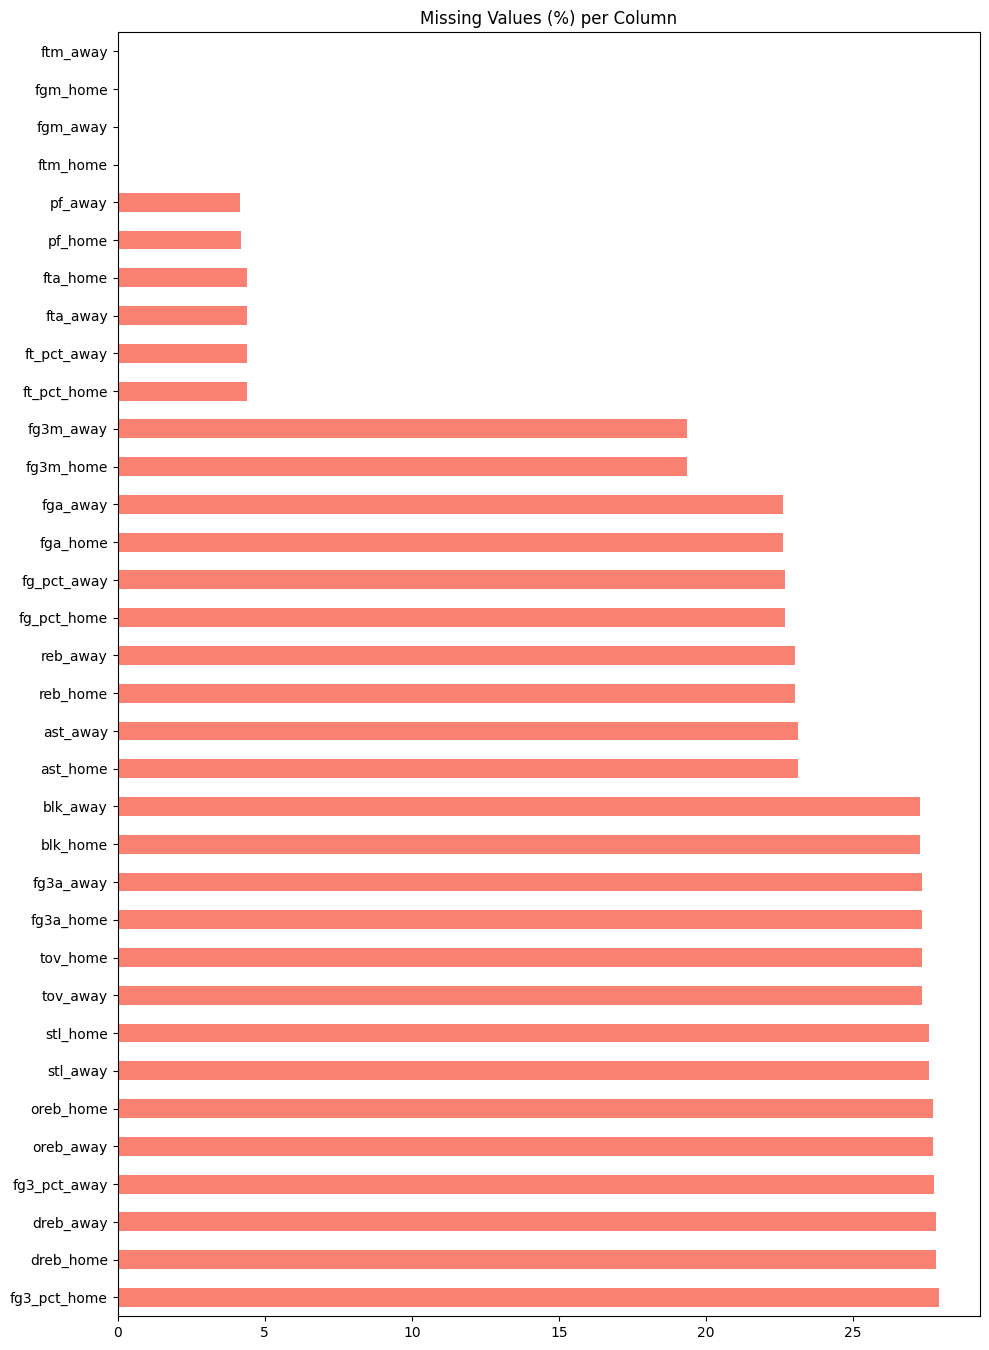

In [10]:
missing_pct = games.isnull().mean() * 100
missing_df  = missing_pct[missing_pct > 0].sort_values(ascending=False)
if not missing_df.empty:
    plt.figure(figsize=(10, max(4, len(missing_df)*0.4)))
    missing_df.plot(kind='barh', color='salmon')
    plt.title('Missing Values (%) per Column')
    plt.tight_layout(); plt.show()
else:
    print('No missing values found')

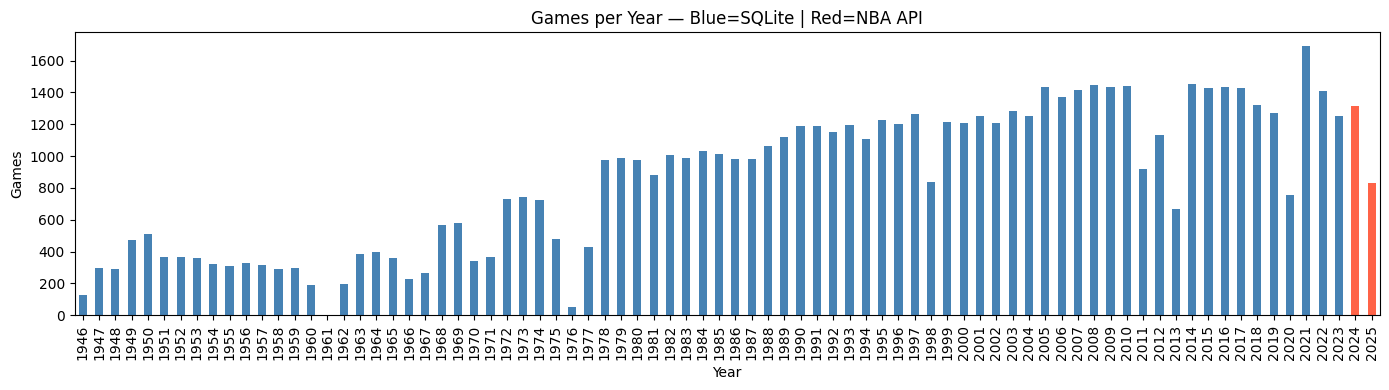

Dataset spans: 1946 to 2025
source
sqlite     65698
nba_api     2621


In [11]:
games_temp = games.copy()
games_temp['game_date']   = pd.to_datetime(games_temp['game_date'], errors='coerce')
games_temp['season_year'] = games_temp['game_date'].dt.year
counts = games_temp['season_year'].value_counts().sort_index()
colors = ['tomato' if y >= 2024 else 'steelblue' for y in counts.index]
plt.figure(figsize=(14, 4))
counts.plot(kind='bar', color=colors)
plt.title('Games per Year — Blue=SQLite | Red=NBA API')
plt.xlabel('Year'); plt.ylabel('Games')
plt.tight_layout(); plt.show()
print(f'Dataset spans: {games_temp["season_year"].min()} to {games_temp["season_year"].max()}')
print(games['source'].value_counts().to_string())

## Step 5 — Apply Recency Cutoff (2018+)

2018 gives ~7+ seasons of the modern 3-point era — enough data for robust ML without including outdated playstyles.

In [12]:
CUTOFF_YEAR = 2018
games['game_date']   = pd.to_datetime(games['game_date'], errors='coerce')
games['season_year'] = games['game_date'].dt.year
before = len(games)
games  = games[games['season_year'] >= CUTOFF_YEAR].copy()
print(f'Rows before: {before:,}  |  After: {len(games):,}  |  Removed: {before-len(games):,}')
print(f'Date range:  {games["game_date"].min().date()} to {games["game_date"].max().date()}')

Rows before: 68,319  |  After: 9,834  |  Removed: 58,485
Date range:  2018-01-01 to 2025-06-22


## Step 6 — Handle Missing Values

In [13]:
missing_pct    = games.isnull().mean() * 100
high_null_cols = missing_pct[missing_pct >= 50].index.tolist()
print(f'Dropping {len(high_null_cols)} high-null columns: {high_null_cols}')
games = games.drop(columns=high_null_cols)

Dropping 0 high-null columns: []


In [14]:
critical_cols = [c for c in ['pts_home','pts_away'] if c in games.columns]
before = len(games)
games  = games.dropna(subset=critical_cols)
if critical_cols:
    games = games[games['pts_home'] + games['pts_away'] > 0]
print(f'Removed {before-len(games):,} rows with missing/zero scores. Remaining: {len(games):,}')

Removed 0 rows with missing/zero scores. Remaining: 9,834


In [15]:
numeric_cols = games.select_dtypes(include=np.number).columns.tolist()
games[numeric_cols] = games[numeric_cols].fillna(games[numeric_cols].median())
for col in games.select_dtypes(include='object').columns:
    if games[col].isnull().any():
        games[col] = games[col].fillna(games[col].mode()[0])
print(f'Missing values remaining: {games.isnull().sum().sum()}')

Missing values remaining: 0


## Step 7 — Remove Duplicates

The 2023 season may appear in both SQLite and the API. We keep the API version on any overlap.

In [16]:
before = len(games)
games  = games.sort_values('source', ascending=True)
if 'game_id' in games.columns:
    games = games.drop_duplicates(subset=['game_id'], keep='last')
elif {'game_date','team_id_home','team_id_away'}.issubset(games.columns):
    games = games.drop_duplicates(subset=['game_date','team_id_home','team_id_away'], keep='last')
else:
    games = games.drop_duplicates(keep='last')
games = games.sort_values('game_date').reset_index(drop=True)
print(f'Duplicate rows removed: {before-len(games):,}  |  Remaining: {len(games):,}')

Duplicate rows removed: 4  |  Remaining: 9,830


## Step 8 — Fix Data Types

In [17]:
stat_keywords = ['pts','fg','ft','reb','ast','stl','blk','tov','pf','pct','plus_minus']
stat_cols = [c for c in games.columns if any(k in c.lower() for k in stat_keywords)]
for col in stat_cols:
    games[col] = pd.to_numeric(games[col], errors='coerce')
games = games.sort_values('game_date').reset_index(drop=True)
print('Data types fixed')
print(games.dtypes)

Data types fixed
ast_away                         float64
fgm_away                         float64
team_abbreviation_away               str
game_id                              str
fta_home                         float64
fg3_pct_home                     float64
team_id_away                      object
team_id_home                      object
fg3a_home                        float64
plus_minus_away                    int64
tov_home                         float64
oreb_home                        float64
fgm_home                         float64
pf_home                          float64
dreb_away                        float64
blk_away                         float64
ast_home                         float64
fta_away                         float64
pts_home                         float64
fga_home                         float64
fg3_pct_away                     float64
plus_minus_home                    int64
reb_away                         float64
tov_away                         float64

## Step 9 — Create Target Variable

Home win rate: 56.0%  |  Away win rate: 44.0%


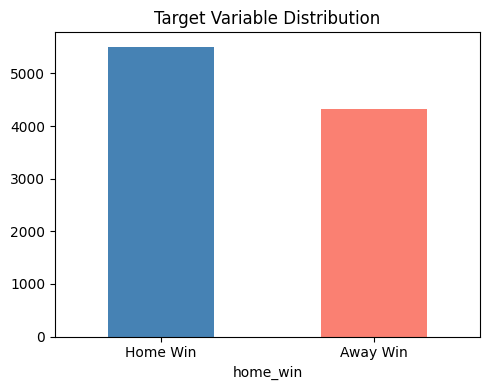

In [18]:
games['home_win'] = (games['pts_home'] > games['pts_away']).astype(int)
win_pct = games['home_win'].mean() * 100
print(f'Home win rate: {win_pct:.1f}%  |  Away win rate: {100-win_pct:.1f}%')
plt.figure(figsize=(5,4))
games['home_win'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.xticks([0,1],['Home Win','Away Win'],rotation=0)
plt.title('Target Variable Distribution')
plt.tight_layout(); plt.show()

## Step 10 — Feature Engineering (Rolling Averages, No Leakage)

We use .shift(1) so only stats from BEFORE the predicted game are used — preventing data leakage.

In [19]:
ROLLING_WINDOW = 10
MIN_PERIODS    = 3

home_stat_cols = [c for c in ['pts_home','fg_pct_home','fg3_pct_home','ft_pct_home',
    'reb_home','ast_home','stl_home','blk_home','tov_home','plus_minus_home'] if c in games.columns]
away_stat_cols = [c for c in ['pts_away','fg_pct_away','fg3_pct_away','ft_pct_away',
    'reb_away','ast_away','stl_away','blk_away','tov_away','plus_minus_away'] if c in games.columns]

games = games.sort_values(['team_id_home','game_date'])
for col in home_stat_cols:
    games[f'{col}_roll{ROLLING_WINDOW}'] = (
        games.groupby('team_id_home')[col]
        .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()))

games = games.sort_values(['team_id_away','game_date'])
for col in away_stat_cols:
    games[f'{col}_roll{ROLLING_WINDOW}'] = (
        games.groupby('team_id_away')[col]
        .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()))

games = games.sort_values(['team_id_home','game_date'])
games['home_win_rate_roll10'] = (
    games.groupby('team_id_home')['home_win']
    .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()))

games = games.sort_values('game_date').reset_index(drop=True)
print(f'Created {len([c for c in games.columns if "roll" in c])} rolling feature columns')

Created 21 rolling feature columns


In [20]:
roll_cols = [c for c in games.columns if 'roll' in c]
before    = len(games)
games     = games.dropna(subset=roll_cols)
print(f'Dropped {before-len(games):,} rows lacking history. Remaining: {len(games):,}')

Dropped 220 rows lacking history. Remaining: 9,610


## Step 11 — Remove Outliers

In [21]:
roll_cols    = [c for c in games.columns if 'roll' in c]
numeric_roll = games[roll_cols].select_dtypes(include=np.number)
z_scores     = np.abs(stats.zscore(numeric_roll, nan_policy='omit'))
outlier_mask = (z_scores < 3).all(axis=1)
before = len(games)
games  = games[outlier_mask].reset_index(drop=True)
print(f'Outliers removed: {before-len(games):,}  |  Remaining: {len(games):,}')

Outliers removed: 520  |  Remaining: 9,090


## Step 12 — Encode Categorical Variables

In [22]:
if 'season_type' in games.columns:
    games = pd.get_dummies(games, columns=['season_type'], drop_first=True)
    print('One-hot encoded: season_type')
le = LabelEncoder()
for col in ['team_id_home','team_id_away']:
    if col in games.columns:
        games[f'{col}_enc'] = le.fit_transform(games[col].astype(str))
        print(f'Label encoded: {col}')
games['is_home_favored'] = 1

One-hot encoded: season_type
Label encoded: team_id_home
Label encoded: team_id_away


## Step 13 — Recency Weighting

Recent games get exponentially higher sample weights so the model prioritises modern patterns.

Sample weight by year:
season_year
2018    0.1225
2019    0.1653
2020    0.2231
2021    0.3012
2022    0.4066
2023    0.5488
2024    0.7408
2025    1.0000


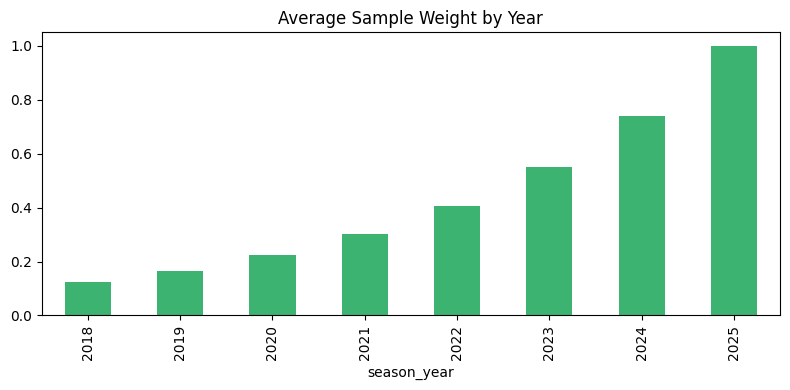

In [23]:
max_year = games['season_year'].max()
games['sample_weight'] = np.exp(0.3 * (games['season_year'] - max_year))
print('Sample weight by year:')
print(games.groupby('season_year')['sample_weight'].mean().round(4).to_string())
plt.figure(figsize=(8,4))
games.groupby('season_year')['sample_weight'].mean().plot(kind='bar', color='mediumseagreen')
plt.title('Average Sample Weight by Year')
plt.tight_layout(); plt.show()

## Step 14 — Select Features and Scale

In [24]:
feature_cols = (
    [c for c in games.columns if 'roll' in c] +
    [c for c in games.columns if c.endswith('_enc')] +
    [c for c in games.columns if c.startswith('season_type_')] +
    ['is_home_favored','home_win_rate_roll10']
)
feature_cols = list(dict.fromkeys([c for c in feature_cols if c in games.columns]))
print(f'Total features: {len(feature_cols)}')
print(feature_cols)

Total features: 26
['pts_home_roll10', 'fg_pct_home_roll10', 'fg3_pct_home_roll10', 'ft_pct_home_roll10', 'reb_home_roll10', 'ast_home_roll10', 'stl_home_roll10', 'blk_home_roll10', 'tov_home_roll10', 'plus_minus_home_roll10', 'pts_away_roll10', 'fg_pct_away_roll10', 'fg3_pct_away_roll10', 'ft_pct_away_roll10', 'reb_away_roll10', 'ast_away_roll10', 'stl_away_roll10', 'blk_away_roll10', 'tov_away_roll10', 'plus_minus_away_roll10', 'home_win_rate_roll10', 'team_id_home_enc', 'team_id_away_enc', 'season_type_Pre Season', 'season_type_Regular Season', 'is_home_favored']


In [25]:
model_df = games[feature_cols + ['home_win','game_date','sample_weight']].dropna().copy()
model_df = model_df.sort_values('game_date').reset_index(drop=True)
X = model_df[feature_cols]
y = model_df['home_win']
weights = model_df['sample_weight']
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
print(f'Feature matrix: {X_scaled.shape}  |  Target: {y.shape}')

Feature matrix: (9090, 26)  |  Target: (9090,)


## Step 15 — Time-Series Train/Test Split

Never use random shuffle splits on sports data — it leaks future games into training.

In [26]:
N_SPLITS = 5
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
print(f'TimeSeriesSplit with {N_SPLITS} folds:')
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_scaled), 1):
    print(f'  Fold {fold}: Train={len(train_idx):,} | Test={len(test_idx):,}')
train_idx, test_idx = list(tscv.split(X_scaled))[-1]
X_train = X_scaled.iloc[train_idx];  X_test  = X_scaled.iloc[test_idx]
y_train = y.iloc[train_idx];         y_test  = y.iloc[test_idx]
w_train = weights.iloc[train_idx];   w_test  = weights.iloc[test_idx]
print(f'Final train: {len(X_train):,}  |  Final test: {len(X_test):,}')

TimeSeriesSplit with 5 folds:
  Fold 1: Train=1,515 | Test=1,515
  Fold 2: Train=3,030 | Test=1,515
  Fold 3: Train=4,545 | Test=1,515
  Fold 4: Train=6,060 | Test=1,515
  Fold 5: Train=7,575 | Test=1,515
Final train: 7,575  |  Final test: 1,515


## Step 16 — Save Clean Dataset

In [27]:
model_df.to_csv('nba_cleaned.csv', index=False)
X_train.assign(home_win=y_train.values, sample_weight=w_train.values).to_csv('nba_train.csv', index=False)
X_test.assign(home_win=y_test.values,   sample_weight=w_test.values).to_csv('nba_test.csv',  index=False)
print('Saved: nba_cleaned.csv  |  nba_train.csv  |  nba_test.csv')

Saved: nba_cleaned.csv  |  nba_train.csv  |  nba_test.csv


## Step 17 — Final Summary

In [28]:
print('=' * 55)
print('          FINAL PIPELINE SUMMARY')
print('=' * 55)
print(f'  Sources:       SQLite (Kaggle) + NBA API')
print(f'  Date range:    {model_df["game_date"].min().date()} to {model_df["game_date"].max().date()}')
print(f'  Total games:   {len(model_df):,}')
print(f'  Features:      {len(feature_cols)}')
print(f'  Train games:   {len(X_train):,}')
print(f'  Test games:    {len(X_test):,}')
print(f'  Home win rate: {y.mean()*100:.1f}%')
print(f'  CV folds:      {N_SPLITS} (TimeSeriesSplit)')
print('=' * 55)
print('Dataset is ready! Usage: model.fit(X_train, y_train, sample_weight=w_train)')

          FINAL PIPELINE SUMMARY
  Sources:       SQLite (Kaggle) + NBA API
  Date range:    2018-01-08 to 2025-06-19
  Total games:   9,090
  Features:      26
  Train games:   7,575
  Test games:    1,515
  Home win rate: 56.0%
  CV folds:      5 (TimeSeriesSplit)
Dataset is ready! Usage: model.fit(X_train, y_train, sample_weight=w_train)


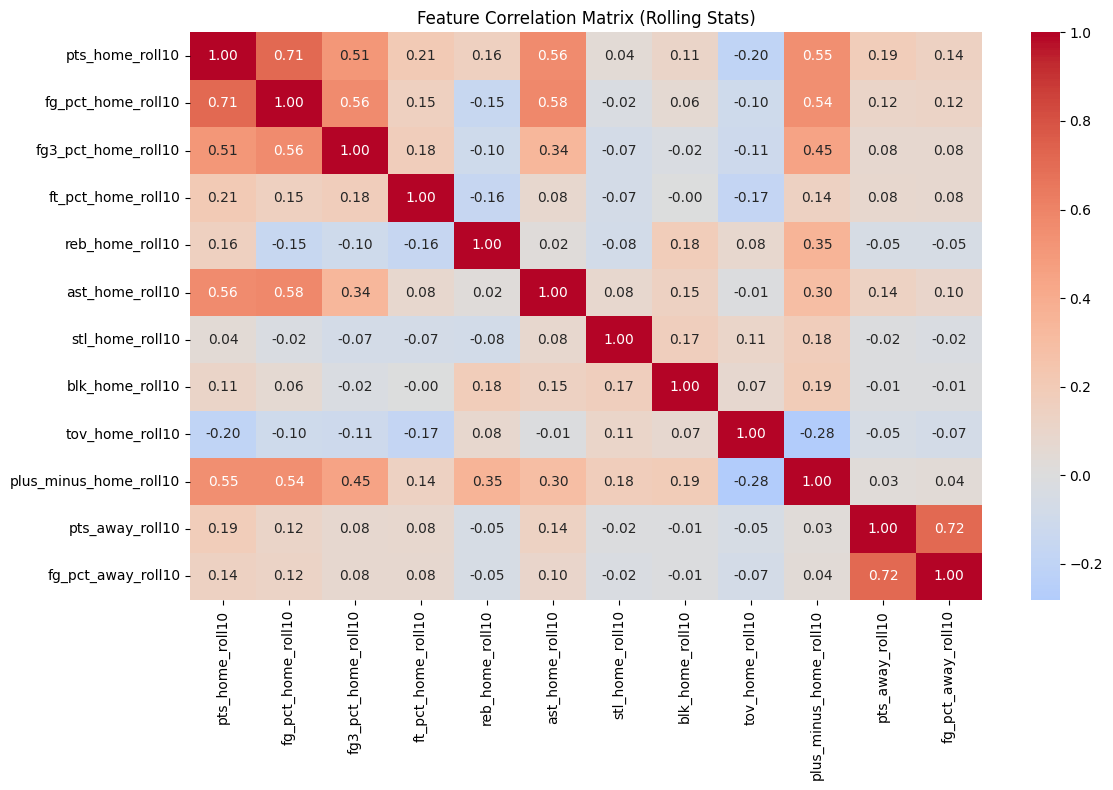

In [29]:
roll_feature_cols = [c for c in X_scaled.columns if 'roll' in c][:12]
if roll_feature_cols:
    plt.figure(figsize=(12,8))
    sns.heatmap(X_scaled[roll_feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix (Rolling Stats)')
    plt.tight_layout(); plt.show()